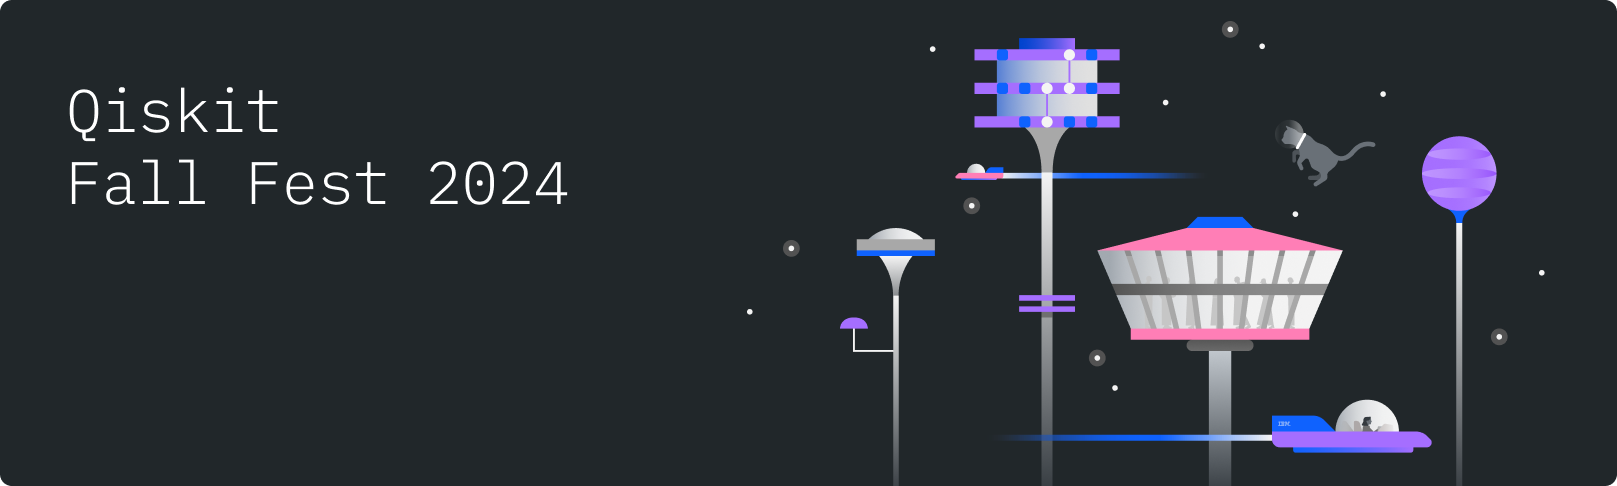

## 🐱 **The Story of Schrödinger's Cat Running Away**

#### The famous Schrödinger's cat decided to escape its owner using the power of quantum randomness! Using a noisy quantum environment and quantum circuits, the cat hides its escape coordinates from Schrödinger, ensuring it is never found.
#### Let's begin the journey with quantum random number generation, noise, and the clever escape of Schrödinger's cat!

In [1]:
#%pip install qiskit
#%pip install qiskit_ibm_runtime
#%pip install qiskit_aer
#%pip install matplotlib
#%pip install pylatexenc

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.primitives import Estimator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeValenciaV2
import math
import numpy as np
import matplotlib.pyplot as plt

## 📏 **Defining the Range and Noise Model**:
#### The range for random number generation is between **10** and **1000**, representing the cat's escape coordinates.

In [3]:
n = 12  # The cat needs a good number of bits to ensure its coordinates are well hidden.
MIN_RANGE = 10  # Minimum coordinate value for the cat's location
MAX_RANGE = 1000  # Maximum coordinate value for the cat's location

## 🧑‍🔬 **Noise Modeling**:
#### We also simulate noise using the **FakeValenciaV2** backend, which mimics real-world errors in quantum devices. We create a noise model to simulate how real-world quantum hardware behaves. A 5% depolarizing error is introduced, random noise is added to quantum gates, causing errors that the cat can use to hide its path from Schrödinger.

In [4]:
backend = AerSimulator()
backend = FakeValenciaV2()  # Using a noisy backend
noise_model = NoiseModel.from_backend(backend)

## 💥 **Adding Depolarizing Errors to the Gates**:
#### Depolarizing errors affect quantum gates, randomly flipping or altering qubit states. This models real-world noise.

In [5]:
error = depolarizing_error(0.05, 1)  # 5% depolarizing error for single-qubit gates
noise_model.add_all_qubit_quantum_error(error, ["u1", "u2", "u3", "u4", "u5"])

## 🐾 **Create Noisy Simulator**:
#### The noisy simulator takes the noise model into account when running the quantum circuit, simulating the cat's random escape.

In [6]:
simulator = AerSimulator(noise_model=noise_model)

## 🧩 **Quantum Functions for Cat's Journey**:

In [7]:
def generate_random_bits(n, simulator):
    """
    Generate n random bits using a quantum circuit with a noisy simulator.
    The cat uses quantum randomness to determine its coordinates while hiding from Schrödinger.
    """
    random_bits = []
    qc = QuantumCircuit(1, 1)
    qc.h(0)  # Hadamard gate creates superposition, the cat is in an uncertain state.
    qc.measure(0, 0)

    qc = transpile(qc, simulator)
    for _ in range(n):
        result = simulator.run(qc, shots=1).result()
        counts = result.get_counts()
        random_bits.append(list(counts.keys())[0])  # Collecting the binary bits from quantum measurement
    return random_bits

def random_number_from_bits(bits):
    """
    Convert random binary bits into an integer, representing the cat's potential escape coordinate.
    """
    return int(''.join(bits), 2)

def number_of_bits_required(min_val, max_val):
    """
    Calculate the number of bits required to represent a coordinate within the specified range.
    """
    return math.ceil(math.log(max_val - min_val + 1, 2))

def generate_random_number(min_val, max_val, simulator):
    """
    Generate a random number within the range [min_val, max_val] using quantum random bits.
    The cat generates this random number to find its new escape location.
    """
    num_bits = number_of_bits_required(min_val, max_val)
    random_num = max_val + 1
    while random_num > max_val:
        random_bits = generate_random_bits(num_bits, simulator)
        random_num = random_number_from_bits(random_bits) + min_val  # Cat finds a valid coordinate
    return random_num, random_bits


## 💬 **User Input for the Number of Random Numbers**:
#### Now, the program prompts the user to decide how many random coordinates the cat will generate for its escape.

In [8]:
while True:
    try:
        num_random_numbers = int(input("Please enter the number of random numbers to generate: "))
        if num_random_numbers <= 0:
            print("Please enter a positive integer.")
        else:
            break
    except ValueError:
        print("Invalid input. Please enter an integer.")

Please enter the number of random numbers to generate:  14


## 🗺️ **Generate Coordinates for the Cat's Escape**:
#### Based on user input, let's generate the random coordinates for the cat's escape.

In [9]:
random_numbers = []
random_bits_list = []
for i in range(num_random_numbers):
    random_num, random_bits = generate_random_number(MIN_RANGE, MAX_RANGE, simulator)
    random_numbers.append(random_num)
    random_bits_list.append(random_bits)

## 🐾 **Display Cat's Escape Coordinates**:
#### The generated coordinates are shown visually with colored boxes, representing where the cat is trying to go.

In [10]:
print("Coordinates for the Cat's Family:", random_numbers)
for i, bits in enumerate(random_bits_list):
    print(f"Quantum Bits for Coordinate {i + 1}:", bits)

Coordinates for the Cat's Family: [648, 536, 432, 39, 261, 858, 334, 691, 435, 925, 296, 263, 443, 779]
Quantum Bits for Coordinate 1: ['1', '0', '0', '1', '1', '1', '1', '1', '1', '0']
Quantum Bits for Coordinate 2: ['1', '0', '0', '0', '0', '0', '1', '1', '1', '0']
Quantum Bits for Coordinate 3: ['0', '1', '1', '0', '1', '0', '0', '1', '1', '0']
Quantum Bits for Coordinate 4: ['0', '0', '0', '0', '0', '1', '1', '1', '0', '1']
Quantum Bits for Coordinate 5: ['0', '0', '1', '1', '1', '1', '1', '0', '1', '1']
Quantum Bits for Coordinate 6: ['1', '1', '0', '1', '0', '1', '0', '0', '0', '0']
Quantum Bits for Coordinate 7: ['0', '1', '0', '1', '0', '0', '0', '1', '0', '0']
Quantum Bits for Coordinate 8: ['1', '0', '1', '0', '1', '0', '1', '0', '0', '1']
Quantum Bits for Coordinate 9: ['0', '1', '1', '0', '1', '0', '1', '0', '0', '1']
Quantum Bits for Coordinate 10: ['1', '1', '1', '0', '0', '1', '0', '0', '1', '1']
Quantum Bits for Coordinate 11: ['0', '1', '0', '0', '0', '1', '1', '1', '1

## 🎨 **Plotting the Coordinates**:
#### Each generated coordinate will be plotted as text inside a rounded box to represent the cat's escape route.

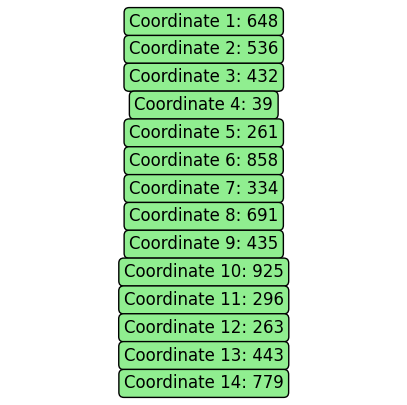

In [11]:
fig, axes = plt.subplots(num_random_numbers, 1, figsize=(5, 5))
for i, ax in enumerate(axes):
    ax.text(0.5, 0.5, f"Coordinate {i + 1}: {random_numbers[i]}", fontsize=12, ha='center', va='center',
            bbox=dict(boxstyle="round", facecolor="lightgreen"))
    ax.axis('off')

## 🌀 **Hiding the Coordinates Using Noise**:
#### To prevent Schrödinger from tracking the cat, we apply noise to the generated coordinates, making them harder to track.

In [12]:
last_random_bits = random_bits_list[-1]
counts = {f"Bit {i}": int(bit) for i, bit in enumerate(last_random_bits)}

## 🧩 **Visualizing the Bit Distribution**:
#### We will visualize how the noisy quantum bits are distributed to hide the coordinates.

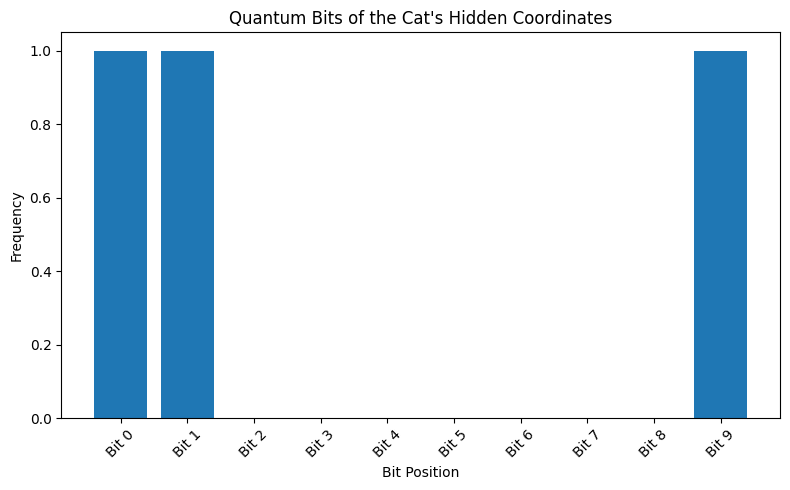

In [13]:
positions = list(range(len(last_random_bits)))  # Bit positions affected by noise
labels = [f"Bit {i}" for i in positions]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(positions, counts.values(), tick_label=labels, align='center')
ax.set_title("Quantum Bits of the Cat's Hidden Coordinates")
ax.set_xlabel("Bit Position")
ax.set_ylabel("Frequency")
plt.xticks(rotation=45)  # Rotate labels for readability
plt.tight_layout()
plt.show()

## 🔒 **Noise Hiding the Coordinates**:
#### A noisy quantum random distribution is generated by introducing random variations in the quantum states' frequencies.

In [14]:
counts = {f"{i:0{n}b}": np.random.randint(80, 120) for i in range(2**n)}  # Noisy quantum state counts

## 🌀 **Normalizing Probabilities**:
#### Normalize the counts to get a probability distribution, simulating noise on the quantum states.
- Advanced quantum circuit for noisy estimation
- Transpile and estimate with noise
- Adjust the observable to match the number of qubits in the transpiled circuit
- Create Estimator

In [15]:
circuit = QuantumCircuit(4)
circuit.h(0)
circuit.cx(0, 1)
circuit.cx(1, 2)
circuit.cx(2, 3)

pass_manager = generate_preset_pass_manager(optimization_level=3, backend=backend)
transpiled_circuit = pass_manager.run(circuit)

observable = SparsePauliOp.from_list(
    [("Z" + "I" * (transpiled_circuit.num_qubits - 1), 1.0)]
)

parameter_values = [[]]  # No parameters to bind
noisy_estimator = Estimator()
noisy_estimator.options.resilience_level = 2
noisy_estimator.options.default_shots = 1024

job = noisy_estimator.run(
    circuits=[transpiled_circuit], observables=[observable], parameter_values=parameter_values
)
result_noise = job.result()
noisy_value = float(result_noise.values[0])
print(f"Noisy Value from Estimator: {noisy_value}")

Noisy Value from Estimator: -0.015625


## Generate noisy counts with random variations for each binary state

In [16]:
n_qubits = 4

counts = {f"{i:0{n_qubits}b}": np.random.randint(80, 120) for i in range(2**n_qubits)}
probabilities = {key: val / sum(counts.values()) for key, val in counts.items()}

## 🌪️ **Sampling from Noisy Distribution**:
#### The cat will "choose" a random location based on this noisy distribution.

In [17]:
random_number = np.random.choice(list(probabilities.keys()), p=list(probabilities.values()))
print(f"Quantum Random Location (Binary): {random_number}")

Quantum Random Location (Binary): 1100


## 📊 **Visualizing the Noisy Quantum Distribution**:
#### We now plot the histogram showing the frequency of each quantum state in the noisy distribution.

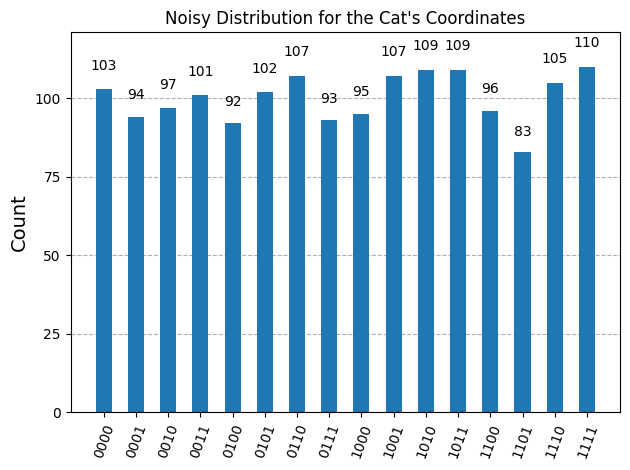

In [18]:
plot_histogram(counts, title="Noisy Distribution for the Cat's Coordinates")

## 😼 **End of the Journey**:
#### The cat has successfully hidden its coordinates using quantum randomness and noise, ensuring Schrödinger will never find its family!